**Source notebook:** [`06_simses_bess_degradation_demo.ipynb`](../../notebooks/06_simses_bess_degradation_demo.ipynb)


# 06 — SimSES BESS Degradation Demonstration for WEC Smoothing Profiles

This optional final notebook connects selected storage-aware smoothing profiles from [Notebook 05](../outputs/pdf/05_storage_smoothing_metrics.pdf) to a simple stationary battery simulation workflow using SimSES.

The goal is not to optimize BESS sizing, validate a battery lifetime model, or produce a bankable degradation study. Instead, the notebook asks:

> Given selected WEC smoothing duty cycles from Notebook 05, how can they be prepared for battery simulation, and what operation and degradation-relevant indicators can be inspected?

The analysis remains a demonstration. The WEC power signal is still the simplified 250 kW proxy developed earlier in the project, and the selected storage profiles remain smoothing-implied duty cycles rather than optimized BESS dispatch schedules. SimSES is used here as a practical battery-simulation tool to illustrate a possible next step in the workflow, not as final validation of battery lifetime or project design.


## 1. Scope, selected profiles, and simulation concept

This notebook builds on the previous workflow steps:

* [Literature map and research context](../outputs/pdf/00_literature_map.pdf)
* [Wave-resource data preparation](../outputs/pdf/01_wave_data_preparation.pdf)
* [Estimated WEC power from sea-state conditions](../outputs/pdf/02_wec_power_estimation.pdf)
* [Short-term point forecasting baselines](../outputs/pdf/03_forecasting_baselines.pdf)
* [Prediction intervals and uncertainty estimation](../outputs/pdf/04_prediction_intervals_uncertainty.pdf)
* [Storage-aware smoothing metrics](../outputs/pdf/05_storage_smoothing_metrics.pdf)
* SimSES BESS degradation demonstration

The previous notebooks prepared open wave-resource observations, estimated WEC power using a simplified generic power-matrix approach, evaluated short-term point forecasts, calibrated empirical prediction intervals, and converted selected grid-export smoothing rules into storage power, energy, throughput, and equivalent-cycle metrics.

This notebook takes one further optional step. It replays selected storage power profiles through a simple SimSES battery model to inspect battery operation and degradation-relevant outputs under WEC smoothing duty cycles.

The selected cases are limited to the 30 min forecast horizon and 2 h smoothing window:

* observed-power smoothing;
* forecast-informed smoothing.

For consistency with the previous forecasting workflow, the forecast-informed smoothing profile replayed here comes from the Ridge point forecast developed in [Notebook 03](../outputs/pdf/03_forecasting_baselines.pdf). The uncertainty-aware lower-bound smoothing profile from [Notebook 05](../outputs/pdf/05_storage_smoothing_metrics.pdf) was based on the 90% conformal-style prediction intervals developed in [Notebook 04](../outputs/pdf/04_prediction_intervals_uncertainty.pdf), but that additional case is not replayed here so that the battery-simulation demonstration remains compact.

The storage power convention follows Notebook 05:

$p_{st} = p_{wec} - p_{grid}$

where:

* $p_{wec}$ is the estimated WEC power;
* $p_{grid}$ is the selected smoothed grid-export target;
* $p_{st}$ is the storage balancing power.

The sign convention is:

* $p_{st} > 0$: storage charges or absorbs surplus relative to the grid-export target;
* $p_{st} < 0$: storage discharges or supports the grid-export target.

The battery replay is organized in two levels. First, one continuous representative segment is used for detailed time-series inspection. This gives an intuitive view of the storage duty cycle, including charge/discharge switching, state-of-charge movement, cumulative throughput, equivalent cycling, and available SimSES state-of-health outputs.

After the detailed segment replay, the selected fold and segment profiles are replayed independently to summarize operation and stress-related indicators across the evaluation data. Because the rolling-origin folds overlap in calendar time and the continuous segments have different durations, these summaries are not treated as one physical lifetime trajectory. Instead, they are reported using descriptive and duration-normalized indicators such as SOC range, throughput per day, equivalent full cycles per day, C-rate proxies, and available degradation-relevant outputs.

The results should therefore be interpreted as reproducible workflow and screening indicators only. They remain conditional on the simplified WEC power estimate, the smoothing rules, the simple BESS sizing assumptions used here, and the specific SimSES battery model configuration.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown


pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True


# Paths are relative to the notebooks/ directory.
NOTEBOOK_ID = "notebook_06"

OUTPUTS_DIR = Path("../outputs")

TABLES_DIR = OUTPUTS_DIR / "tables" / NOTEBOOK_ID
FIGURES_DIR = OUTPUTS_DIR / "figures" / NOTEBOOK_ID
NOTEBOOK_OUTPUT_DIR = OUTPUTS_DIR / NOTEBOOK_ID

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


STORAGE_TIMESERIES_PATH = (
    OUTPUTS_DIR
    / "notebook_05"
    / "storage_smoothing_timeseries.parquet"
)

STORAGE_METRICS_SUMMARY_PATH = (
    OUTPUTS_DIR
    / "tables"
    / "notebook_05"
    / "storage_smoothing_metrics_summary.csv"
)

STORAGE_METRICS_BY_FOLD_PATH = (
    OUTPUTS_DIR
    / "tables"
    / "notebook_05"
    / "storage_smoothing_metrics_by_fold.csv"
)

## 2. Inputs from the storage-smoothing notebook

This section loads the storage-smoothing time series and summary tables generated by [Notebook 05](../outputs/pdf/05_storage_smoothing_metrics.pdf). These files contain the smoothed grid-export targets, implied storage balancing power, fold-level metrics, and overall smoothing summaries used for the battery replay demonstration.

In [3]:
storage_timeseries = pd.read_parquet(STORAGE_TIMESERIES_PATH)
storage_metrics_summary = pd.read_csv(STORAGE_METRICS_SUMMARY_PATH)
storage_metrics_by_fold = pd.read_csv(STORAGE_METRICS_BY_FOLD_PATH)

storage_timeseries["target_time"] = pd.to_datetime(storage_timeseries["target_time"])

input_summary = pd.DataFrame(
    [
        ["Storage smoothing time series", STORAGE_TIMESERIES_PATH, len(storage_timeseries)],
        ["Storage metrics summary", STORAGE_METRICS_SUMMARY_PATH, len(storage_metrics_summary)],
        ["Storage metrics by fold", STORAGE_METRICS_BY_FOLD_PATH, len(storage_metrics_by_fold)],
    ],
    columns=["Input", "Path", "Rows"],
)

display(Markdown(input_summary.to_markdown(index=False)))

| Input                         | Path                                                                |   Rows |
|:------------------------------|:--------------------------------------------------------------------|-------:|
| Storage smoothing time series | ../outputs/notebook_05/storage_smoothing_timeseries.parquet         | 166582 |
| Storage metrics summary       | ../outputs/tables/notebook_05/storage_smoothing_metrics_summary.csv |     52 |
| Storage metrics by fold       | ../outputs/tables/notebook_05/storage_smoothing_metrics_by_fold.csv |    260 |

## 3. Selected smoothing profiles

This section selects the two storage-smoothing profiles used in the battery replay demonstration. Both profiles use the 30 min forecast horizon and the 2 h smoothing window from [Notebook 05](../outputs/pdf/05_storage_smoothing_metrics.pdf).

The two selected cases are:

* observed-power smoothing;
* forecast-informed smoothing.

The fold-level metrics are used to define conservative battery sizing assumptions later in the notebook. In particular, the battery power and usable-energy requirements are taken from the maximum values across folds rather than from fold-averaged values.

In [5]:
SELECTED_HORIZON_STEPS = 1
SELECTED_SMOOTHING_WINDOW_MIN = 120
SELECTED_SCENARIOS = ["B", "C"]

selected_timeseries = storage_timeseries[
    (storage_timeseries["horizon_steps"] == SELECTED_HORIZON_STEPS)
    & (storage_timeseries["smoothing_window_min"] == SELECTED_SMOOTHING_WINDOW_MIN)
    & (storage_timeseries["scenario"].isin(SELECTED_SCENARIOS))
].copy()

selected_metrics_by_fold = storage_metrics_by_fold[
    (storage_metrics_by_fold["horizon_steps"] == SELECTED_HORIZON_STEPS)
    & (storage_metrics_by_fold["smoothing_window_min"] == SELECTED_SMOOTHING_WINDOW_MIN)
    & (storage_metrics_by_fold["scenario"].isin(SELECTED_SCENARIOS))
].copy()

selected_summary = (
    selected_metrics_by_fold
    .groupby(["scenario", "scenario_name"], observed=True)
    .agg(
        n_folds=("fold_id", "nunique"),
        max_storage_power_rating_kw=("storage_power_rating_kw", "max"),
        max_required_usable_energy_kwh=("required_energy_kwh", "max"),
        mean_throughput_kwh=("throughput_kwh", "mean"),
        mean_equivalent_full_cycles=("equivalent_full_cycles", "mean"),
        mean_ramp_p95_reduction_percent=("ramp_p95_reduction_percent", "mean"),
    )
    .reset_index()
)

selected_summary["scenario"] = pd.Categorical(
    selected_summary["scenario"],
    categories=SELECTED_SCENARIOS,
    ordered=True,
)

selected_summary = (
    selected_summary
    .sort_values("scenario")
    .reset_index(drop=True)
)

selected_summary_display = selected_summary.copy()

numeric_cols = selected_summary_display.select_dtypes(include="number").columns
selected_summary_display[numeric_cols] = selected_summary_display[numeric_cols].round(2)

selected_summary_display.columns = (
    selected_summary_display.columns
    .str.replace("_", " ", regex=False)
)

display(Markdown(selected_summary_display.to_markdown(index=False)))

| scenario   | scenario name               |   n folds |   max storage power rating kw |   max required usable energy kwh |   mean throughput kwh |   mean equivalent full cycles |   mean ramp p95 reduction percent |
|:-----------|:----------------------------|----------:|------------------------------:|---------------------------------:|----------------------:|------------------------------:|----------------------------------:|
| B          | Observed-power smoothing    |         5 |                         31.39 |                            62.83 |                890.81 |                          8.44 |                             70.53 |
| C          | Forecast-informed smoothing |         5 |                         41.41 |                           225.38 |               1685.04 |                          4.17 |                             81.21 |

## 4. Representative continuous replay segment

Before running the battery simulation, one continuous segment is selected for detailed time-series inspection. This segment is used to show the battery operation more intuitively than a collection of short independent replays.

The selected segment is taken from the same 30 min horizon and 2 h smoothing-window profiles defined above. It is used for both selected smoothing cases so that the observed-power and forecast-informed profiles can be compared over the same time period.

The purpose of this detailed segment is to inspect the storage duty cycle, SOC movement, cumulative throughput, equivalent cycling, and available SimSES degradation-relevant outputs under a continuous WEC smoothing period. The later cross-segment summary will then replay all selected fold/segment profiles independently and report duration-normalized indicators.

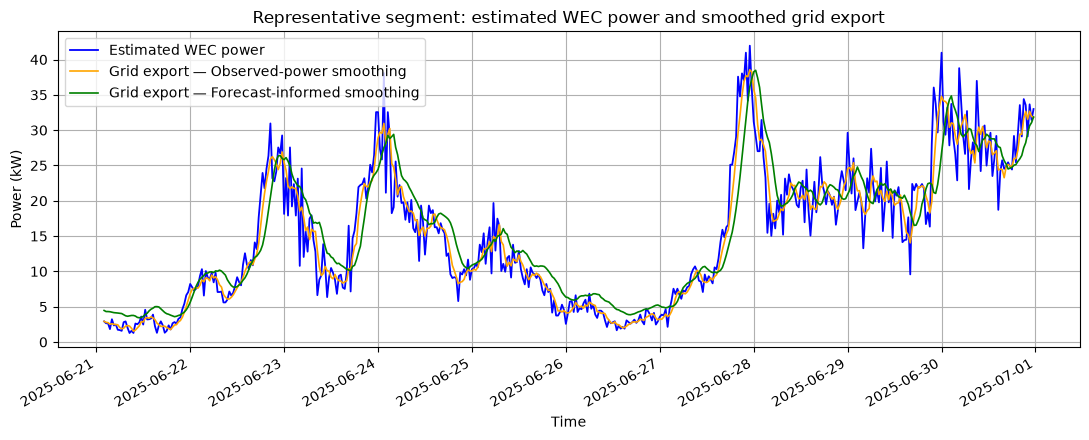

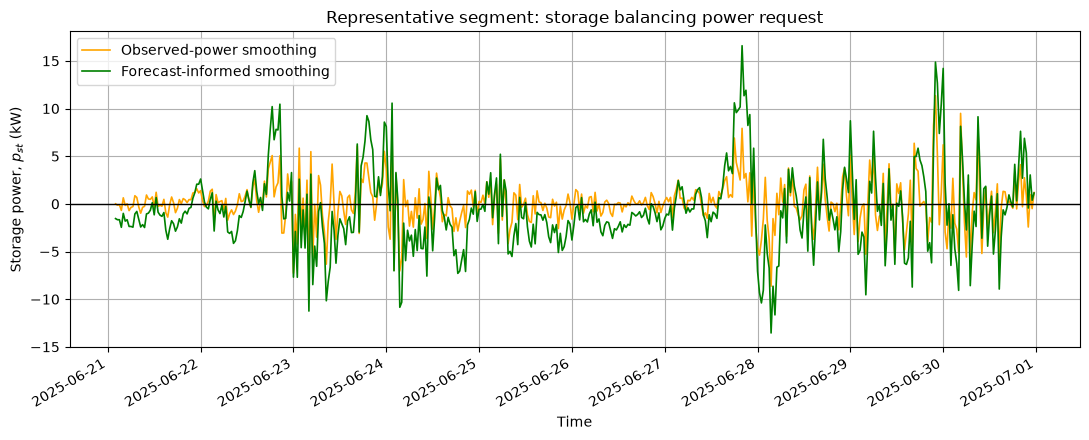

Saved representative-segment figures:

* `../outputs/figures/notebook_06/representative_segment_grid_power.png`
* `../outputs/figures/notebook_06/representative_segment_storage_power.png`

| scenario   | scenario name               | start time          | end time            |   n samples |   duration hours |   duration days |   max abs storage power kw |   required energy kwh |   throughput kwh |
|:-----------|:----------------------------|:--------------------|:--------------------|------------:|-----------------:|----------------:|---------------------------:|----------------------:|-----------------:|
| B          | Observed-power smoothing    | 2025-06-21 02:00:00 | 2025-06-30 23:30:00 |         476 |              238 |            9.92 |                      11.35 |                 36.05 |           412.3  |
| C          | Forecast-informed smoothing | 2025-06-21 02:00:00 | 2025-06-30 23:30:00 |         476 |              238 |            9.92 |                      16.59 |                189.64 |           751.36 |

In [8]:
TIME_STEP_HOURS = 0.5

REPRESENTATIVE_FOLD_ID = 5
REPRESENTATIVE_SEGMENT_ID = "h1_fold5_seg5"

SCENARIO_COLOR_MAP = {
    "B": "orange",
    "C": "green",
}

representative_segment = selected_timeseries[
    (selected_timeseries["fold_id"] == REPRESENTATIVE_FOLD_ID)
    & (selected_timeseries["segment_id"] == REPRESENTATIVE_SEGMENT_ID)
].copy()

if representative_segment.empty:
    raise ValueError(
        "The selected representative segment was not found in the selected time series."
    )

if representative_segment["scenario"].nunique() != len(SELECTED_SCENARIOS):
    raise ValueError(
        "The representative segment does not contain all selected smoothing scenarios."
    )

representative_segment = representative_segment.sort_values(
    ["scenario", "target_time"]
).reset_index(drop=True)


# Plot WEC power and smoothed grid-export targets.
fig, ax = plt.subplots(figsize=(11, 4.5))

wec_reference = (
    representative_segment
    .drop_duplicates(subset=["target_time"])
    .sort_values("target_time")
)

ax.plot(
    wec_reference["target_time"],
    wec_reference["p_wec_kw"],
    linewidth=1.3,
    color="blue",
    label="Estimated WEC power",
)

for scenario, scenario_df in representative_segment.groupby(
    "scenario",
    observed=True,
):
    scenario_df = scenario_df.sort_values("target_time")
    scenario_name = scenario_df["scenario_name"].iloc[0]

    ax.plot(
        scenario_df["target_time"],
        scenario_df["p_grid_kw"],
        linewidth=1.2,
        color=SCENARIO_COLOR_MAP[scenario],
        label=f"Grid export — {scenario_name}",
    )

ax.set_title("Representative segment: estimated WEC power and smoothed grid export")
ax.set_xlabel("Time")
ax.set_ylabel("Power (kW)")
ax.legend(loc="best")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

grid_power_plot_path = FIGURES_DIR / "representative_segment_grid_power.png"
fig.savefig(grid_power_plot_path, dpi=300, bbox_inches="tight")
plt.show()


# Plot storage balancing power request.
fig, ax = plt.subplots(figsize=(11, 4.5))

for scenario, scenario_df in representative_segment.groupby(
    "scenario",
    observed=True,
):
    scenario_df = scenario_df.sort_values("target_time")
    scenario_name = scenario_df["scenario_name"].iloc[0]

    ax.plot(
        scenario_df["target_time"],
        scenario_df["p_st_kw"],
        linewidth=1.2,
        color=SCENARIO_COLOR_MAP[scenario],
        label=scenario_name,
    )

ax.axhline(0, linewidth=1.0, color="black")
ax.set_title("Representative segment: storage balancing power request")
ax.set_xlabel("Time")
ax.set_ylabel("Storage power, $p_{st}$ (kW)")
ax.legend(loc="best")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

storage_power_plot_path = FIGURES_DIR / "representative_segment_storage_power.png"
fig.savefig(storage_power_plot_path, dpi=300, bbox_inches="tight")
plt.show()


display(
    Markdown(
        "Saved representative-segment figures:\n\n"
        f"* `{grid_power_plot_path}`\n"
        f"* `{storage_power_plot_path}`"
    )
)


representative_segment_summary = (
    representative_segment
    .groupby(["scenario", "scenario_name"], observed=True)
    .agg(
        start_time=("target_time", "min"),
        end_time=("target_time", "max"),
        n_samples=("target_time", "size"),
        max_abs_storage_power_kw=("abs_storage_power_kw", "max"),
        required_energy_kwh=("required_energy_kwh", "max"),
        throughput_kwh=("abs_storage_power_kw", lambda s: s.sum() * TIME_STEP_HOURS),
    )
    .reset_index()
)

representative_segment_summary["duration_hours"] = (
    representative_segment_summary["n_samples"] * TIME_STEP_HOURS
)

representative_segment_summary["duration_days"] = (
    representative_segment_summary["duration_hours"] / 24
)

representative_segment_summary = representative_segment_summary[
    [
        "scenario",
        "scenario_name",
        "start_time",
        "end_time",
        "n_samples",
        "duration_hours",
        "duration_days",
        "max_abs_storage_power_kw",
        "required_energy_kwh",
        "throughput_kwh",
    ]
]

representative_segment_display = representative_segment_summary.copy()

numeric_cols = representative_segment_display.select_dtypes(include="number").columns
representative_segment_display[numeric_cols] = (
    representative_segment_display[numeric_cols].round(2)
)

representative_segment_display.columns = (
    representative_segment_display.columns
    .str.replace("_", " ", regex=False)
)

display(Markdown(representative_segment_display.to_markdown(index=False)))